In [1]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import os

In [2]:
def calculate_area_in_km2(gdf):
    # Step 1: Set target CRS to EPSG:4326
    target_crs = 'EPSG:4326'
    gdf = gdf.to_crs(target_crs)
    
    # Step 2: Reproject to a CRS with meters (e.g., EPSG:3857)
    projected_gdf = gdf.to_crs('EPSG:3857')
    
    # Step 3: Calculate the area in square meters
    projected_gdf['area_m2'] = projected_gdf.geometry.area
    
    # Step 4: Convert the area to square kilometers
    projected_gdf['area_km2'] = projected_gdf['area_m2'] / 1e6
    
    # Step 5: Assign the calculated area to a new column in the original GeoDataFrame
    gdf['area_km2'] = projected_gdf['area_km2']
    
    # Step 6: Return the modified GeoDataFrame
    return gdf


In [4]:

def check_overlap(df, year_col='SURVEY_YEAR', geometry_col='geometry'):
    """
    Remove elements that overlap with others within the last 10 years and the next 5 years.
    """
    df = df.copy()
    overlaps = set()

    # Iterate over each row to check for overlaps
    for i, row in df.iterrows():
        year = row[year_col]
        geom = row[geometry_col]

        # Define the time window for overlap check
        time_window = (df[year_col] >= (year - 10)) & (df[year_col] <= (year + 5))

        # Check for spatial overlaps within the time window
        spatial_overlaps = df[time_window][df[geometry_col].intersects(geom)]
        
        # Add the indices of the overlapping rows to the overlaps set
        if len(spatial_overlaps) > 1:
            overlaps.add(i)
            overlaps.update(spatial_overlaps.index)

    # Drop the overlapping rows
    df = df.drop(index=overlaps)
    return df

# Exploring USDA Disturbance Data for Region 8

This Python script performs data processing tasks on USDA disturbance data for Region 8. The script follows a series of steps to filter, manipulate, and save the data for further analysis. Here's a breakdown of what each step accomplishes:

1. **Loading CSV File**: The script begins by loading the USDA disturbance data from a CSV file located at `/Net/Groups/BGI/work_2/ForExD/USDA/tables/CONUS_Region8_dissolved.csv` into a Pandas DataFrame.

2. **Converting WKT Geometries**: The WKT (Well-Known Text) geometries in the DataFrame are converted into Shapely geometries. This step ensures that the spatial data can be processed and analyzed using Geopandas.

3. **Converting to GeoDataFrame**: The DataFrame is converted into a GeoDataFrame, enabling spatial operations and visualization.

4. **Filtering Data**: Disturbance records outside the timeframe of 2016 to 2020 are filtered out. Additionally, specific disturbance types such as 'other', 'multi_damage', 'other_abiotic', and 'other_biotic' are excluded from the analysis.

5. **Renaming Columns**: The column 'Unnamed: 0' is renamed to 'index_usda' for clarity and consistency.

6. **Exploding Multipolygons**: Multipolygon geometries are exploded into individual polygons. This step ensures that each polygon is treated as a separate entity for analysis.

7. **Saving Results**: The processed GeoDataFrame is saved as a CSV file named `region8_dca_id_filtered_usda_polygons.csv`. The file is saved in the directory `/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results`.

8. **Confirmation Message**: Finally, a confirmation message is printed, indicating that the results have been successfully saved to the specified location.

This script streamlines the data processing workflow, allowing researchers to efficiently analyze USDA disturbance data for Region 8.

In [4]:
# Step 1: Read the CSV file into a DataFrame
print("Step 1: Loading CSV file...")
input_file = "/Net/Groups/BGI/work_2/ForExD/USDA/tables_new/CONUS_Region8_dissolved.csv"
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the coordinate reference system (CRS) if it's not already set
gdf.set_crs(epsg=4326, inplace=True)

print(f"Number of elements: {len(gdf)}")

# Step 4: Filter for disturbances recorded between 2016 and 2020
print("Step 4: Filtering disturbances recorded between 2016 and 2020...")
gdf_timeframe = gdf[(gdf['SURVEY_YEAR'] > 2016) & (gdf['SURVEY_YEAR'] <= 2020)]

# Filter out specific disturbance types
excluded_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
rslt_df = gdf_timeframe[~gdf_timeframe['DCA_ID'].isin(excluded_types)].copy()

print(f"Number of elements withing the timeframe and dirturbance types: {len(rslt_df)}")

# Step 5: Rename the column 'Unnamed: 0' to 'index_usda'
print("Step 5: Rename columns for clarity and consistency")
rslt_df.rename(columns={'Unnamed: 0': 'index_usda'}, inplace=True)

# Step 6: Explode multipolygons into individual polygons
print("Step 6: Exploding multipolygons into individual polygons...")
exploded_df = rslt_df.explode(index_parts=True)

# Reset the index to ensure a clean index
exploded_df.reset_index(drop=True, inplace=True)

# Step 7: Generate new index_usda values
print("Step 7: Generating new index_usda values...")
exploded_df['USDA_IDX'] = exploded_df.apply(lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1)

# Step 8: Calculating area in km²
print("Step 8: Calculating area in km²")
gdf_with_area = calculate_area_in_km2(exploded_df)

# Step 9: Remove elements larger than 15km²
print("Step 9: Remove elements larger than 15km²")
filtered_gdf = gdf_with_area[gdf_with_area['area_km2'] <= 15]
filtered_gdf.reset_index()
# Print the number of remaining elements
print(f"Number of elements after filtering: {len(filtered_gdf)}")

# Define the absolute path to the "results" folder
results_folder = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results"

# Define the output CSV file path
output_file = os.path.join(results_folder, "region8_dca_filtered_ids_usda_polygons.shp")

# Step 8: Save the exploded DataFrame to a CSV file in the results folder
print(f"Step 8: Saving results to: {output_file}...")
filtered_gdf.to_file(output_file, index=False)

# Display the path of the saved CSV file
print(f"Results saved to: {output_file}")

Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Step 4: Filtering disturbances recorded between 2016 and 2020...
Step 5: Rename columns for clarity and consistency
Step 6: Exploding multipolygons into individual polygons...
Step 7: Generating new index_usda values...
Step 8: Calculating area in km²
Step 9: Remove elements larger than 15km²
Number of elements after filtering: 19193
Step 8: Saving results to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.shp...


/tmp/ipykernel_1894451/3487350680.py:59: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_gdf.to_file(output_file, index=False)


Results saved to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.shp


In [5]:
filtered_gdf.head()

,index_usda,DCA_ID,SURVEY_YEAR,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,geometry,USDA_IDX,area_km2
0,32095,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14245,"POLYGON ((-86.09680 32.14270, -86.09685 32.142...",bark_beetle_2017_0,0.005641
1,32096,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14246,"POLYGON ((-86.01648 32.01100, -86.01655 32.011...",bark_beetle_2017_1,0.011262
2,32097,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14247,"POLYGON ((-86.24623 32.06300, -86.24629 32.063...",bark_beetle_2017_2,0.011274
3,32098,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14248,"POLYGON ((-86.08565 32.05823, -86.08572 32.058...",bark_beetle_2017_3,0.011273
4,32099,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14249,"POLYGON ((-87.40289 32.86707, -87.40294 32.867...",bark_beetle_2017_4,0.005732


<Axes: >

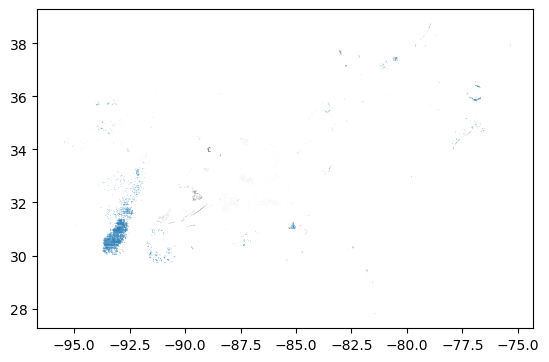

In [6]:
filtered_gdf.plot()

In [5]:
# Step 1: Read the CSV file into a DataFrame
print("Step 1: Loading CSV file...")
input_file = "/Net/Groups/BGI/work_2/ForExD/USDA/tables_new/CONUS_Region8_dissolved.csv"
df = pd.read_csv(input_file)

# Step 2: Convert the WKT geometries to Shapely geometries
print("Step 2: Converting WKT geometries...")
df['geometry'] = df['geometry'].apply(wkt.loads)

# Step 3: Convert the DataFrame to a GeoDataFrame
print("Step 3: Converting DataFrame to GeoDataFrame...")
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Set the coordinate reference system (CRS) if it's not already set
gdf.set_crs(epsg=4326, inplace=True)

# Step 4: Check for overlaps
print("Step 4: Checking for temporal and spatial overlaps...")
gdf_no_overlap = check_overlap(gdf)

print(f"Number of elements: {len(gdf)}")
print(f"Number of elements after removing temporlar spatial overlaps: {len(gdf_no_overlap)}")

# Step 5: Filter for disturbances recorded between 2016 and 2020
print("Step 5: Filtering disturbances recorded between 2016 and 2020...")
gdf_timeframe = gdf_no_overlap[(gdf_no_overlap['SURVEY_YEAR'] > 2016) & (gdf_no_overlap['SURVEY_YEAR'] <= 2020)]

# Filter out specific disturbance types
excluded_types = ['other', 'multi_damage', 'other_abiotic', 'other_biotic']
rslt_df = gdf_timeframe[~gdf_timeframe['DCA_ID'].isin(excluded_types)].copy()

print(f"Number of elements withing the timeframe and dirturbance types: {len(rslt_df)}")

# Step 6: Rename the column 'Unnamed: 0' to 'index_usda'
print("Step 6: Rename columns for clarity and consistency")
rslt_df.rename(columns={'Unnamed: 0': 'index_usda'}, inplace=True)

# Step 7: Explode multipolygons into individual polygons
print("Step 7: Exploding multipolygons into individual polygons...")
exploded_df = rslt_df.explode(index_parts=True)

# Reset the index to ensure a clean index
exploded_df.reset_index(drop=True, inplace=True)

# Step 8: Generate new index_usda values
print("Step 8: Generating new index_usda values...")
exploded_df['USDA_IDX'] = exploded_df.apply(lambda row: f"{row['DCA_ID']}_{row['SURVEY_YEAR']}_{row.name}", axis=1)

# Step 9: Calculating area in km²
print("Step 9: Calculating area in km²")
gdf_with_area = calculate_area_in_km2(exploded_df)

# Step 10: Remove elements larger than 15km²
print("Step 10: Remove elements larger than 15km²")
filtered_gdf = gdf_with_area[gdf_with_area['area_km2'] <= 15]
filtered_gdf.reset_index()
# Print the number of remaining elements
print(f"Number of elements after filtering: {len(filtered_gdf)}")

# Define the absolute path to the "results" folder
results_folder = "/Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results"

# Define the output CSV file path
output_file = os.path.join(results_folder, "region8_dca_filtered_ids_usda_polygons.shp")

# Step 11: Save the exploded DataFrame to a CSV file in the results folder
print(f"Step 11: Saving results to: {output_file}...")
filtered_gdf.to_file(output_file, index=False)

# Display the path of the saved CSV file
print(f"Results saved to: {output_file}")


Step 1: Loading CSV file...
Step 2: Converting WKT geometries...
Step 3: Converting DataFrame to GeoDataFrame...
Step 4: Checking for temporal and spatial overlaps...


/Net/Groups/BGI/scratch/fmueller/miniconda3/envs/emp/lib/python3.8/site-packages/geopandas/geodataframe.py:1475: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


Number of elements: 68916
Number of elements after removing temporlar spatial overlaps: 35363
Step 5: Filtering disturbances recorded between 2016 and 2020...
Number of elements withing the timeframe and dirturbance types: 9206
Step 6: Rename columns for clarity and consistency
Step 7: Exploding multipolygons into individual polygons...
Step 8: Generating new index_usda values...
Step 9: Calculating area in km²
Step 10: Remove elements larger than 15km²
Number of elements after filtering: 9215
Step 11: Saving results to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.shp...


/tmp/ipykernel_3612048/1959241873.py:68: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  filtered_gdf.to_file(output_file, index=False)


Results saved to: /Net/Groups/BGI/scratch/fmueller/ForExD-WP1-P1/results/region8_dca_filtered_ids_usda_polygons.shp


<Axes: >

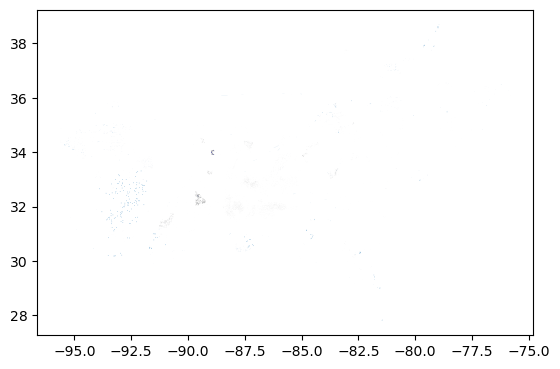

In [6]:
filtered_gdf.plot()

In [9]:
filtered_gdf

,index_usda,DCA_ID,SURVEY_YEAR,REGION_ID,DAMAGE_TYPE,DAMAGE_TYPE_CODE,DCA_CODE,DA_Code_USDA,PERCENT_AFFECTED,HOST,HOST_CODE,cluster_id,geometry,USDA_IDX,area_km2
0,32095,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14245,"POLYGON ((-86.09680 32.14270, -86.09685 32.142...",bark_beetle_2017_0,0.005641
1,32096,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14246,"POLYGON ((-86.01648 32.01100, -86.01655 32.011...",bark_beetle_2017_1,0.011262
2,32097,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14247,"POLYGON ((-86.24623 32.06300, -86.24629 32.063...",bark_beetle_2017_2,0.011274
3,32098,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14248,"POLYGON ((-86.08565 32.05823, -86.08572 32.058...",bark_beetle_2017_3,0.011273
4,32099,bark_beetle,2017,8,Mortality,2,11003,1,No Data,NaN,-1.0,14249,"POLYGON ((-87.40289 32.86707, -87.40294 32.867...",bark_beetle_2017_4,0.005732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9222,56552,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Severe (30-50%),NaN,NaN,19838,"POLYGON ((-88.36541 36.09120, -88.26354 36.080...",wind_2020_9222,7.410090
9223,56553,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19839,"POLYGON ((-85.81513 36.15473, -85.84284 36.152...",wind_2020_9223,1.494372
9225,56555,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19841,"POLYGON ((-85.44200 36.10658, -85.44203 36.106...",wind_2020_9225,0.031742
9227,56557,wind,2020,8,Main stem Broken or Uprooted,7,50013,16,Moderate (11-29%),NaN,NaN,19843,"POLYGON ((-85.02250 36.14265, -84.99754 36.137...",wind_2020_9227,1.906103
